## Project : Anomalies detection with PyTorch
ISAE-SUPAERO, OTSU

Project supervisor : Adrien Elfassi (adrien.elfassi@airbus.com)

The aim of this practical is to detect anomalies in the ‘test_set.pkl’ dataset. 
The task involves training a model based on autoencoders or variational autoencoders on a 
training dataset that contains no anomalies, and then evaluating the reconstruction error on the
test dataset.
By setting a threshold on the reconstruction error, we will be able to detect the anomalies.
The deliverable for this practical is to identify the indices containing an anomaly in the test dataset.


In [3]:
!pip install torchsummary

import pickle
import matplotlib.pyplot as plt
import numpy as np
import os
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchsummary import summary
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, utils
import torch.nn.functional as F
from torch.autograd import Variable
from torchvision.utils import save_image

import torch; torch.manual_seed(0)
import torch.nn as nn
import torch.nn.functional as F
import torch.utils
import torch.distributions
import torchvision
import numpy as np
import matplotlib.pyplot as plt

device = 'cuda' if torch.cuda.is_available() else 'cpu'

## Loading of satellite telemetry data

> training_set.pkl is the training dataset. It was saved in pickle format. 
It consists of 500 two-dimensional time-series. Each dimension contains 1440 samples. <br>

> test_set.pkl is the test dataset.It was saved in pickle format. 
It consists of 230 two dimensional time-series. Each dimensions contains 1440 samples. <br>
Among the 230 time-series, which ones are contain anomalies ? <br>
Let us find out !

In [27]:
training_set = pickle.load(open("./data/training_set.pkl","rb"))    
test_set = pickle.load(open("./data/test_set.pkl","rb"))

# Project beginning

## Class and functions creation

In [ ]:
def normalize(data):  
    
# This function normalises the data and maps each curve to a value between 0 and 1 by subtracting the minimum value and then dividing by the maximum value 
   
    for i in range(np.shape(data)[0]):
        for j in range(2):
            max = np.max(data[i, :, j])
            min = np.min(data[i, :, j])
            data[i, :, j] = (data[i, :, j] - min ) / ( max - min )         
    return data

In [ ]:
# We create the first building block of the two-part autoencoder : the Encoder. Its attributes are the different layers of weights. 

class Encoder(nn.Module):
    def __init__(self, latent_dims):
        super(Encoder, self).__init__()
        self.linear1 = nn.Linear(2880, 1000)
        self.linear2 = nn.Linear(1000, 512)
        self.linear3 = nn.Linear(512, latent_dims)
    
    def forward(self, x):
        #x = torch.flatten(x, start_dim=1)
        x = F.relu(self.linear1(x))
        x = F.relu(self.linear2(x))
        return self.linear3(x)

In [ ]:
# We create the second building block of the autoencoder : the Decoder. 

class Decoder(nn.Module):
    def __init__(self, latent_dims):
        super(Decoder, self).__init__()
        self.linear1 = nn.Linear(latent_dims, 512)
        self.linear2 = nn.Linear(512, 1000)
        self.linear3 = nn.Linear(1000, 2880)
        
    def forward(self, z):
        z = F.relu(self.linear1(z))
        z = F.relu(self.linear2(z))
        z = torch.sigmoid(self.linear3(z))
        #z = self.linear2(z)
        return z

In [31]:
class Autoencoder(nn.Module):
    def __init__(self, latent_dims):
        super(Autoencoder, self).__init__()
        self.encoder = Encoder(latent_dims)
        self.decoder = Decoder(latent_dims)
    
    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z)

In [ ]:
def train(autoencoder, data, epochs=40):
    
    # This function trains the autoencoder on a dataset and returns both the trained autoencoder and the loss profile
    
    opt = torch.optim.Adam(autoencoder.parameters())
    loss_tot = []
    for epoch in range(epochs):
        for x in data:
            x = x.to(device) # GPU
            opt.zero_grad()
            x_hat = autoencoder(x)
            loss = ((x - x_hat)**2).sum()
            loss_tot.append(loss)
            loss.backward()
            opt.step()
            
    return autoencoder, loss_tot

In [ ]:
def test(autoencoder, data):
    
    # This function tests a dataset on the autoencoder and returns a loss profile along with the reconstructed data from the decoder
    
    loss_tot = []
    output_data = []
    for x in data:
        x = x.to(device) # GPU
        x_hat = autoencoder(x)
        loss = ((x - x_hat)**2).sum()
        loss_tot.append(loss)
        
        l = int( np.shape(x_hat.cpu().detach().numpy())[-1]/2 )  #size of the original data for the purpose of reconstructing the encoder output
        x_hat_sh = x_hat.cpu().detach().numpy().reshape((l, 2))
        output_data.append(x_hat_sh)
            
    return loss_tot, np.asarray(output_data)

## Preliminary observation of the data

We observe here the data on two channels, before and after normalisation.

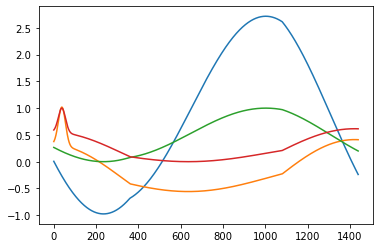

In [34]:
n = 5 

plt.figure()
plt.plot(training_set[n, :, 0])
plt.plot(training_set[n, :, 1])

training_set = normalize(training_set)

plt.plot(training_set[n, :, 0])
plt.plot(training_set[n, :, 1])

## Autoencoder training

### Data organisation

In [35]:
training_set = pickle.load(open("./data/training_set.pkl","rb"))    

latent_dims = 4
autoencoder = Autoencoder(latent_dims).to(device) # GPU

training_set_norm = training_set
training_set_norm = normalize(training_set_norm)
training_set_norm = np.swapaxes(training_set_norm,1,2)
training_set_norm = training_set_norm.astype(float)
training_set_norm = training_set_norm.reshape((500,2880))
training_set_norm = torch.from_numpy(training_set_norm).float()

data_train = torch.utils.data.DataLoader(
        training_set_norm,
        batch_size=50,
        shuffle=True)

### Training

In [36]:
autoencoder, loss_train = train(autoencoder, data_train)

### Visualisation of the training loss

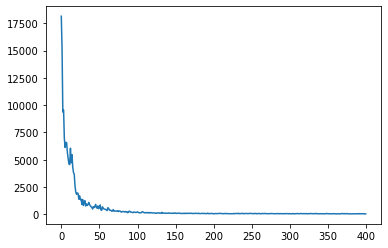

In [37]:
plt.figure()
plt.plot(loss_train)

## Autoencoder test on the training data

### Data organisation

In [38]:
training_set = pickle.load(open("./data/training_set.pkl","rb"))    

data_test_1 = torch.utils.data.DataLoader(
        training_set_norm,
        batch_size=1,
        shuffle=True)

### Test and Visualisation of the results

To verify the test, we examine the loss profile, the data format, and finally the difference between the data at the decoder output and the data at the encoder input.

(500, 1440, 2)


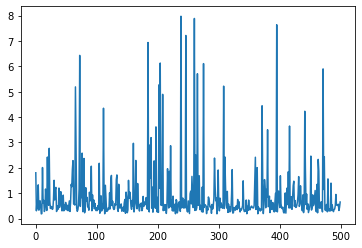

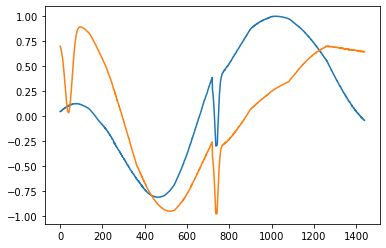

In [39]:
loss_test_1, output_data_train = test(autoencoder, data_test_1)

plt.figure()
plt.plot(loss_test_1)
print(np.shape(output_data_train))

m = 50

tr_set = normalize(training_set)
plt.figure()
plt.plot(tr_set[m, :, 0] - output_data_train[m, :, 0])
plt.plot(tr_set[m, :, 1] - output_data_train[m, :, 1])

## Définition of the anomaly loss threshold

We define the the threshold as the maximum value of the loss on the training data set, when tested against an already trained autoencoder,

In [ ]:
valeur_seuil = max(loss_test_1).cpu()
valeur_seuil = valeur_seuil.detach().numpy()
print('La valeur seuil est : ', valeur_seuil) # Indicates the loss threshold for anomalies

La valeur seuil est :  7.976727


## Test of the autoencoder on the test data set

### Data organisation

In [41]:
test_set = pickle.load(open("./data/test_set.pkl","rb"))

test_set_norm = test_set
test_set_norm = normalize(test_set_norm)
test_set_norm = np.swapaxes(test_set_norm,1,2)
test_set_norm = test_set_norm.astype(float)
test_set_norm = test_set_norm.reshape((230,2880))
test_set_norm = torch.from_numpy(test_set_norm).float()

data_test_2 = torch.utils.data.DataLoader(
        test_set_norm,
        batch_size=1,
        shuffle=False)

### Test and visualisation of the loss profile

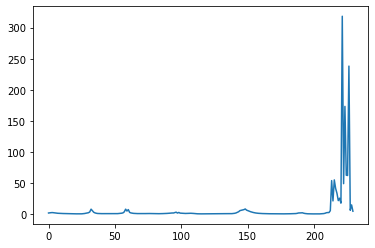

In [42]:
loss_test_2, output_data_test = test(autoencoder, data_test_2)

plt.plot(loss_test_2)

### Anomalies identification

In [ ]:
idx = []
for i in range(len(loss_test_2)):
    if loss_test_2[i].cpu().detach().numpy() >= valeur_seuil:
        idx.append(i)
print('Le nombre d anomalies détectées est : ', len(idx)) # Number of detected anomalies 
print('Les données anormales sont d indice : ', idx) # Index of the detected anomalies

Le nombre d anomalies détectées est :  16
Les données anormales sont d indice :  [148, 213, 214, 215, 216, 217, 218, 219, 220, 221, 222, 223, 224, 225, 226, 228]


### Anomalies visualisation

<Figure size 432x288 with 0 Axes>

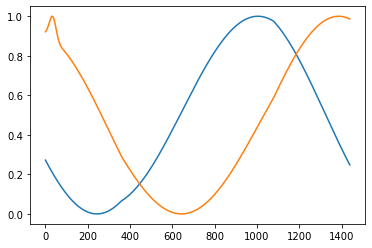

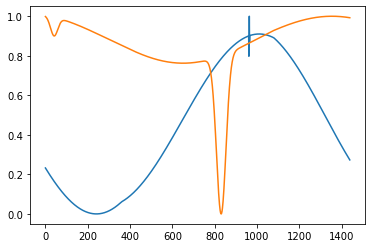

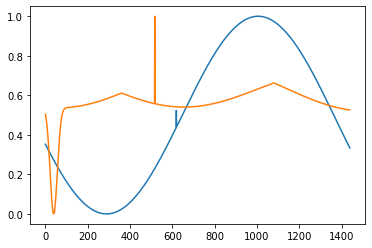

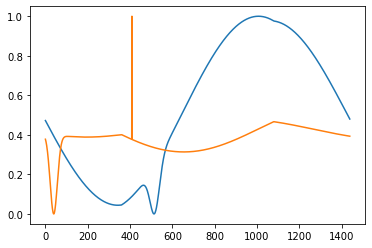

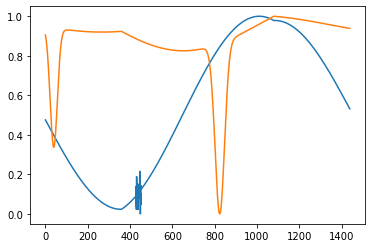

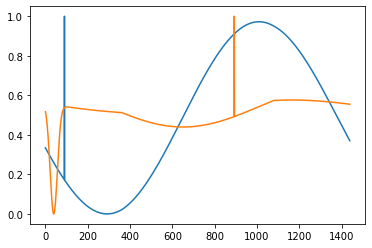

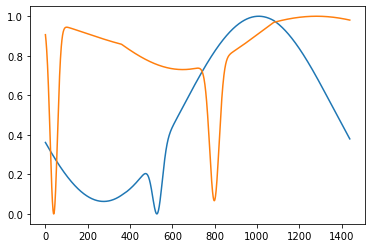

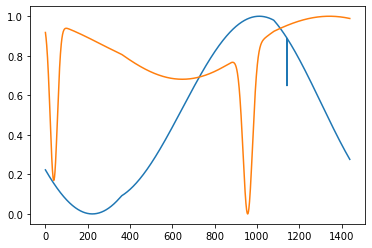

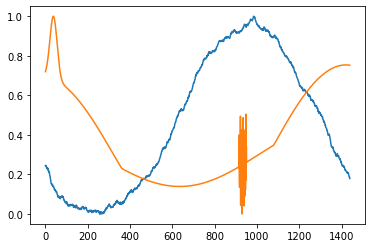

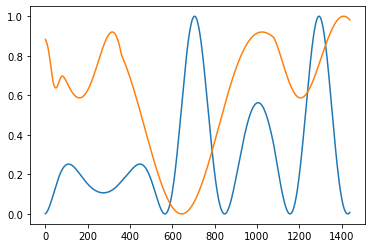

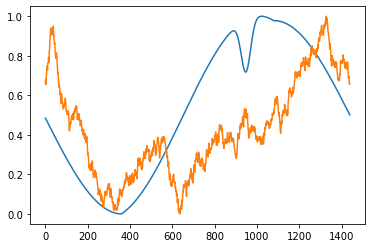

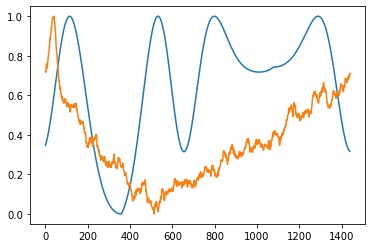

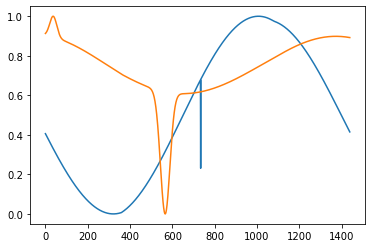

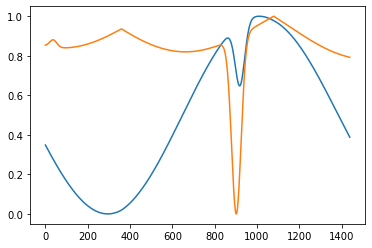

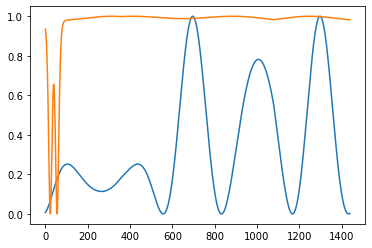

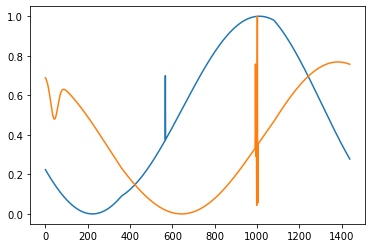

In [ ]:
# We visualise the detected anomalies in order to make sure of our results

for i in idx:
    plt.figure()
    plt.plot(test_set[i, :, 0])
    plt.plot(test_set[i, :, 1])

It would appear that, with the exception of three data points, all data points identified as anomalous are indeed anomalies. However, some anomalous data points were not detected. The autoencoder therefore performs very well, but could nevertheless be improved through the use of convolutions, a variational approach, or a greater number of linear layers.

# Variational Autoencoder

Regardons maintenant un autoencodeur variationnel, toujours avec des couches linéaires.
Let us now construct, train and test a variational autoencoder, still with linear layers.

## Re-Definition of the classes and functions

In [239]:
vae = True

class VariationalEncoder(nn.Module):
    def __init__(self, latent_dims):
        super(VariationalEncoder, self).__init__()
        self.linear1 = nn.Linear(2880, 1000)
        self.linear2 = nn.Linear(1000, 512)
        
        self.linear3 = nn.Linear(512, latent_dims)
        self.linear4 = nn.Linear(512, latent_dims)
        
        self.N = torch.distributions.Normal(0, 1)
        self.N.loc = self.N.loc.cuda() # hack to get sampling on the GPU
        self.N.scale = self.N.scale.cuda()
        self.kl = 0
    
    def forward(self, x):
        #x = torch.flatten(x, start_dim=1)
        x = F.relu(self.linear1(x))
        x = F.relu(self.linear2(x))
        mu =  self.linear3(x)
        sigma = torch.exp(self.linear4(x))
        z = mu + sigma*self.N.sample(mu.shape)
        self.kl = (sigma**2 + mu**2 - torch.log(sigma) - 1/2).sum()
        return z

In [240]:
class Decoder_vae(nn.Module):
    def __init__(self, latent_dims):
        super(Decoder_vae, self).__init__()
        self.linear1 = nn.Linear(latent_dims, 512)
        self.linear2 = nn.Linear(512, 1000)
        self.linear3 = nn.Linear(1000, 2880)
        
    def forward(self, z):
        z = F.relu(self.linear1(z))
        z = F.relu(self.linear2(z))
        z = torch.sigmoid(self.linear3(z))
        return z

In [241]:
class VariationalAutoencoder(nn.Module):
    def __init__(self, latent_dims):
        super(VariationalAutoencoder, self).__init__()
        self.encoder = VariationalEncoder(latent_dims)
        self.decoder = Decoder_vae(latent_dims)
    
    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z)

In [242]:
def train_vae(autoencoder, data, epochs=40):
    opt = torch.optim.Adam(autoencoder.parameters())
    loss_tot = []
    for epoch in range(epochs):
        for x in data:
            x = x.to(device) # GPU
            opt.zero_grad()
            x_hat = autoencoder(x)
            loss = ((x - x_hat)**2).sum() + autoencoder.encoder.kl
            loss_tot.append(loss)
            loss.backward()
            opt.step()
        
        if epoch % 5 == 0:
            print("{} %".format(100 * epoch / epochs))
            
    return autoencoder, loss_tot

In [243]:
def test_vae(autoencoder, data):
    
    # Cette fonction teste un jeu de données sur l'autoencodeur et renvoie un profil de perte ainsi que la reconstruction des données en sortie du décodeur
    
    loss_tot = []
    output_data = []
    i=1
    for x in data:
        x = x.to(device) # GPU
        x_hat = autoencoder(x)
        loss = ((x - x_hat)**2).sum()
        loss_tot.append(loss)
        
        if i ==1:
            print( np.shape(x_hat.cpu().detach().numpy()))
            i+=1
            
        x_cpu = x_hat.cpu().detach().numpy()    
        l = int(np.shape(x_cpu)[-1]/2 )  #taille des données originelles en vue de la reconstruction de la sortie de l'encodeur
        #x_cpu = np.transpose(x_cpu)
        #x_cpu = x_cpu.reshape((1440, 2))
        if i ==2:
            print( np.shape(x_cpu))
            i+=1
        #x_hat_sh = x_hat.cpu().detach().numpy()
        output_data.append(x_cpu)
            
    return loss_tot, np.asarray(output_data)

## Entrainement de l'autoencodeur variationnel

### Mise en forme des données 

In [244]:
training_set = pickle.load(open("./data/training_set.pkl","rb"))    

latent_dims = 4
autoencoder_vae = VariationalAutoencoder(latent_dims).to(device) # GPU

training_set_norm = training_set
training_set_norm = normalize(training_set_norm)
training_set_norm = np.swapaxes(training_set_norm,1,2)
training_set_norm = training_set_norm.astype(float)
training_set_norm = training_set_norm.reshape((500,2880))
training_set_norm = torch.from_numpy(training_set_norm).float()

data_train_vae = torch.utils.data.DataLoader(
        training_set_norm,
        batch_size=5,
        shuffle=True)

### Apprentisage

In [245]:
autoencoder_vae, loss_train_vae = train(autoencoder_vae, data_train_vae, 100)

0.0 %
5.0 %
10.0 %
15.0 %
20.0 %
25.0 %
30.0 %
35.0 %
40.0 %
45.0 %
50.0 %
55.0 %
60.0 %
65.0 %
70.0 %
75.0 %
80.0 %
85.0 %
90.0 %
95.0 %


### Visualisation of the loss profile

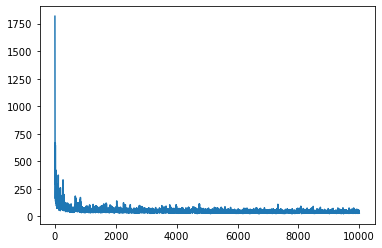

In [246]:
plt.plot(loss_train_vae)

## Test of the variational autoencoder

### Test on the training data set

In [247]:
data_test_1_vae = torch.utils.data.DataLoader(training_set_norm, batch_size=1)

loss_test_1_vae, x_hat_train = test_vae(autoencoder_vae, data_test_1_vae)

(1, 2880)
(1, 2880)


### Visualisation of the decoder output

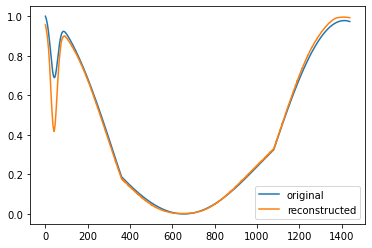

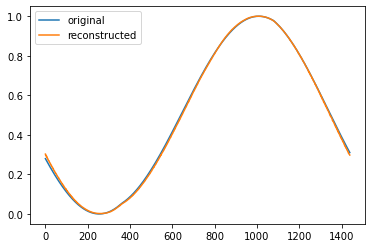

In [248]:
indx = 400
normalize(training_set)


x = x_hat_train[indx]
x = x.reshape((2, 1440))

plt.figure()
plt.plot(training_set[indx, :, 1], label='original')
plt.plot(x[1], label='reconstructed')
plt.legend()

plt.figure()
plt.plot(training_set[indx, :, 0], label='original')
plt.plot(x[0], label='reconstructed')
plt.legend()

### Visualisation of the loss profile

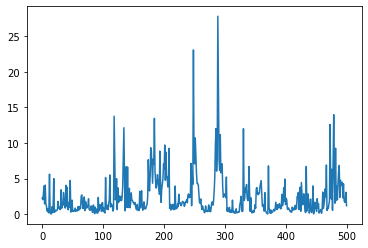

In [249]:
plt.figure()
plt.plot(loss_test_1_vae)

In [ ]:
valeur_seuil_vae = max(loss_test_1_vae).cpu()
valeur_seuil_vae = valeur_seuil_vae.detach().numpy()
print('La valeur seuil est : ', valeur_seuil_vae) # Definition of the anomaly threshold

La valeur seuil est :  27.815235


## Test data set

### Data organisation

In [251]:
test_set = pickle.load(open("./data/test_set.pkl","rb"))

test_set_norm = test_set
test_set_norm = normalize(test_set_norm)
test_set_norm = np.swapaxes(test_set_norm,1,2)
test_set_norm = test_set_norm.astype(float)
test_set_norm = test_set_norm.reshape((230,2880))
test_set_norm = torch.from_numpy(test_set_norm).float()

data_test_2_vae = torch.utils.data.DataLoader(test_set_norm, batch_size=1)

### Test on the test data set

In [252]:
loss_test_2_vae, x_hat_test = test_vae(autoencoder_vae, data_test_2_vae)

(1, 2880)
(1, 2880)


### Visualisation of the decoder output

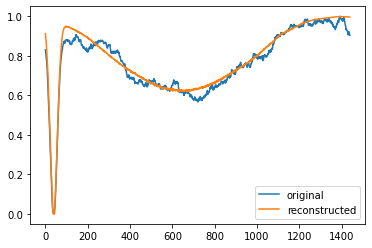

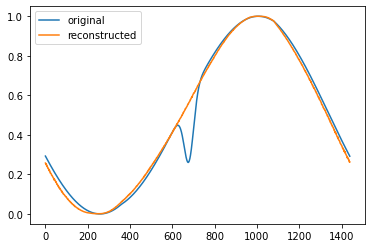

In [253]:
indx2 = 227
normalize(test_set)


x = x_hat_test[indx2]
x = x.reshape((2, 1440))

plt.figure()
plt.plot(test_set[indx2, :, 1], label='original')
plt.plot(x[1], label='reconstructed')
plt.legend()

plt.figure()
plt.plot(test_set[indx2, :, 0], label='original')
plt.plot(x[0], label='reconstructed')
plt.legend()

### Visualisation of the test data set loss

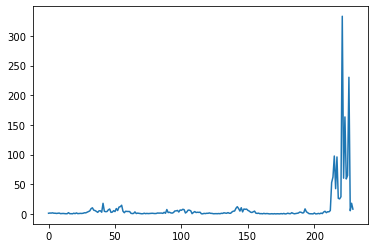

In [254]:
plt.figure()
plt.plot(loss_test_2_vae)

### Anomaly identification

In [ ]:
idx_vae = []
for i in range(len(loss_test_2_vae)):
    if loss_test_2_vae[i].cpu().detach().numpy() >= valeur_seuil_vae:
        idx_vae.append(i)
print('Le nombre d anomalies détectées est : ', len(idx_vae)) # Print the number of anomalies
print('Les données anormales sont d indice : ', idx_vae) # Print the index of the anomalies

Le nombre d anomalies détectées est :  12
Les données anormales sont d indice :  [213, 214, 215, 216, 217, 220, 221, 222, 223, 224, 225, 226]


### Visualisation of the anomalies

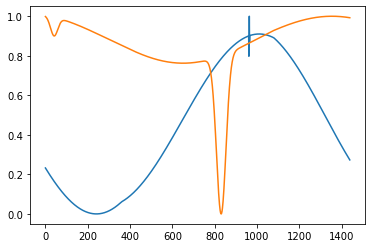

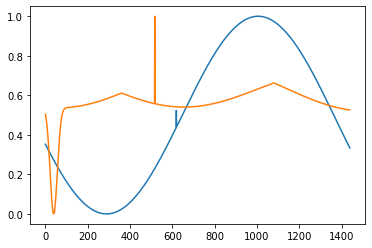

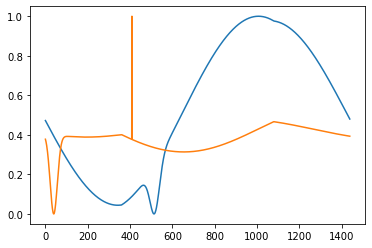

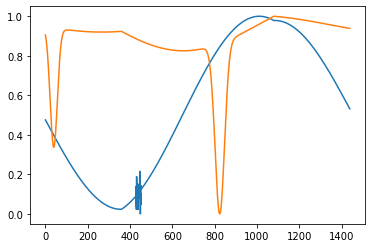

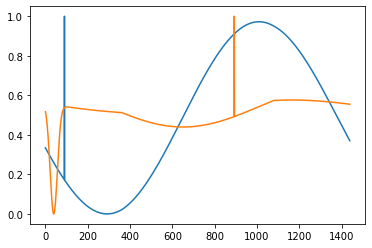

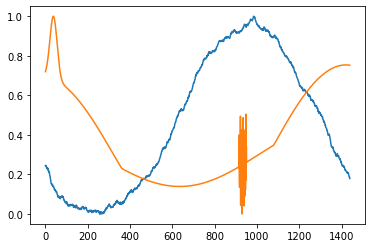

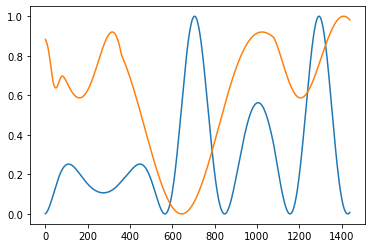

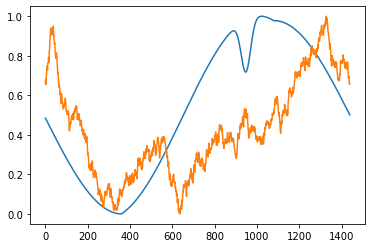

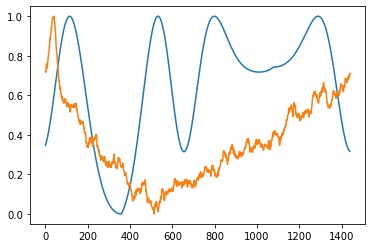

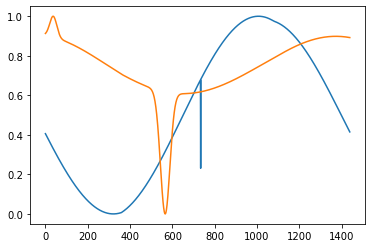

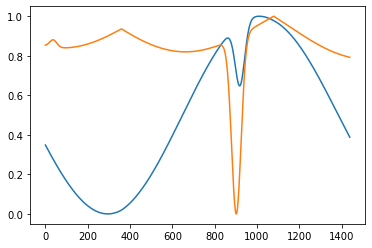

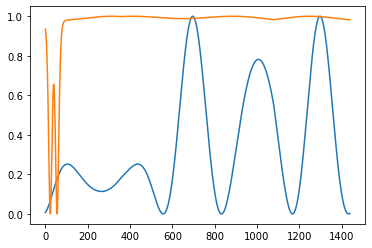

In [256]:
for i in idx_vae:
    plt.figure()
    plt.plot(test_set[i, :, 0])
    plt.plot(test_set[i, :, 1])

Many anomalies are detected, but it appears that an equal number of false positives occur, whilst fewer true anomalies are found compared to the ‘classical’ autoencoder. This may be due to the number of layers, or perhaps the number of available samples was not large enough, meaning that the latent space was not properly sampled.